# Notebook 05 - Event Audio Augmentation

Author: Stellars Henson<br>
Approach: the two synthesized impact sounds - the body thump (notebook 03) and the door clang (notebook 04) - are mixed into the real event recording at the impact moment, producing an augmented recording. The augmented track carries the impact sound the original capture is being tested against.

The modelling lives in the `henryk_simulations.corridor.audiomix` library; this notebook is a thin client over its staged functions.

## Model decisions

- **The synthesized sounds come from notebooks 03 and 04.** The body thump (`03-body-thump.wav`) and the door clang (`04-door-clang.wav`) are the WAV files those notebooks write.
- **The peak lands at a configurable moment.** Each synthesized sound's loudest sample is aligned to `peak_time` in the event timeline - here the 15th second.
- **The mix is peak-limited.** The event recording and the two sounds are summed; if the sum would clip it is scaled down to the configured headroom.
- **m4a via bundled ffmpeg.** Decode and encode use the ffmpeg binary bundled with `imageio-ffmpeg`; no system ffmpeg is required.

In [1]:
%load_ext autoreload
%autoreload 2

# Imports
from __future__ import annotations

import dataclasses
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# Project library - the event-audio augmentation lives in the corridor submodule
from henryk_simulations.corridor.audiomix import (
    AudioMixConfig,
    decode_audio,
    encode_m4a,
    load_synth_sound,
    mix_event,
)

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-18 14:42:45.298 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)

## Configuration

`AudioMixConfig` is the single configuration object - the event-recording and synthesized-sound paths, the peak-alignment moment, the per-sound gains, the working sample rate and the output file. Every section below reads from it.

In [3]:
CFG = AudioMixConfig()
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

cfg_tbl = Table(show_header=False, box=None, padding=(0, 2))
cfg_tbl.add_column("field", style="bold cyan")
cfg_tbl.add_column("value")
for f in dataclasses.fields(CFG):
    cfg_tbl.add_row(f.name, f"[white]{getattr(CFG, f.name)}[/white]")
console.print(Panel(cfg_tbl, title="[bold green]AudioMixConfig[/bold green]",
                    border_style="green"))

╭──────────────────────────────────────────────── AudioMixConfig ─────────────────────────────────────────────────╮
│   event_path        data/external/event_audio/event_recording.m4a                                               │
│   thump_path        reports/figures/03-body-thump.wav                                                           │
│   clang_path        reports/figures/04-door-clang.wav                                                           │
│   output_path       reports/figures/augmented_event_recording.m4a                                               │
│   peak_time         15.0                                                                                        │
│   thump_gain        2.0                                                                                         │
│   clang_gain        1.0                                                                                         │
│   sample_rate       44100                                                                                       │
│   output_bitrate    192k                                                                                        │
│   headroom          0.97                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## The Event Recording

The real capture of the event is decoded to a mono float signal at the working sample rate. Its waveform is the baseline the synthesized impact sounds are mixed into; the dashed line marks the impact moment the sounds are aligned to.

event recording: 26.0 s, 1,146,668 samples at 44100 Hz

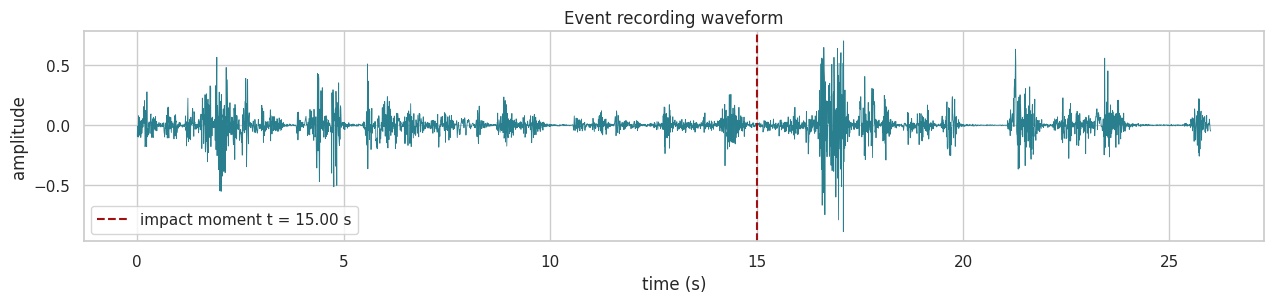

In [4]:
event = decode_audio(CFG.event_path, CFG.sample_rate)
duration = len(event) / CFG.sample_rate
console.print(f"event recording: [white]{duration:.1f} s[/white], "
              f"[white]{len(event):,}[/white] samples at {CFG.sample_rate} Hz")

t_event = np.arange(len(event)) / CFG.sample_rate
step = max(1, len(event) // 4000)
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(t_event[::step], event[::step], color="#2a7f8f", lw=0.6)
ax.axvline(CFG.peak_time, color="#a01010", lw=1.5, ls="--",
           label=f"impact moment t = {CFG.peak_time:.2f} s")
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.set_title("Event recording waveform")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05-event-waveform.png", dpi=140, bbox_inches="tight")
plt.show()

## The Synthesized Impact Sounds

The body thump from notebook 03 and the door clang from notebook 04, loaded as mono float signals. Each carries a silent lead-in before the impact, so the loudest sample - marked - is the impact itself; that is the sample aligned to the event timeline.

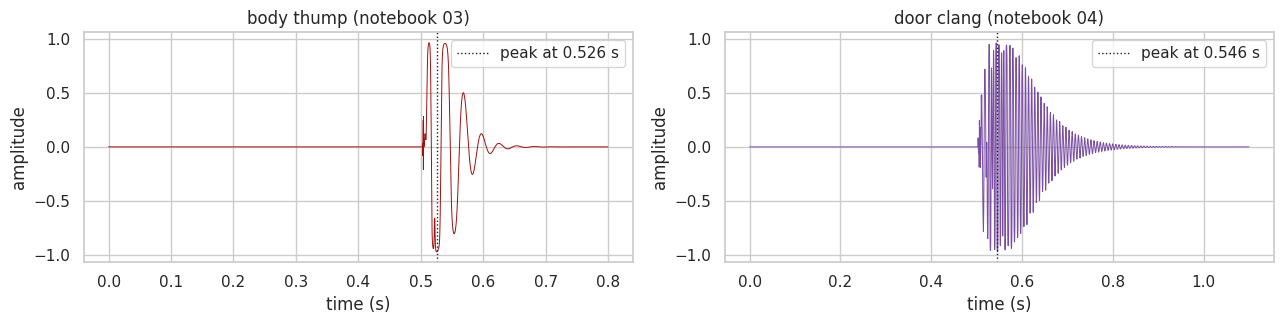

In [5]:
thump = load_synth_sound(CFG.thump_path, CFG.sample_rate)
clang = load_synth_sound(CFG.clang_path, CFG.sample_rate)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
for ax, sig, name, col in [(axes[0], thump, "body thump (notebook 03)", "#a01010"),
                           (axes[1], clang, "door clang (notebook 04)", "#7a4fa3")]:
    t = np.arange(len(sig)) / CFG.sample_rate
    ax.plot(t, sig, color=col, lw=0.7)
    peak = int(np.argmax(np.abs(sig)))
    ax.axvline(peak / CFG.sample_rate, color="#202020", lw=1.0, ls=":",
               label=f"peak at {peak / CFG.sample_rate:.3f} s")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("amplitude")
    ax.set_title(name)
    ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05-synth-sounds.png", dpi=140, bbox_inches="tight")
plt.show()

## Aligning the Impact and Mixing

Each synthesized sound is laid onto the event timeline with its loudest sample on `peak_time`, then summed with the event recording. The mix is peak-limited to stay within headroom; the limiting gain is reported.

peak aligned to sample 661,500 (15.000 s); clip-limiting gain 0.331

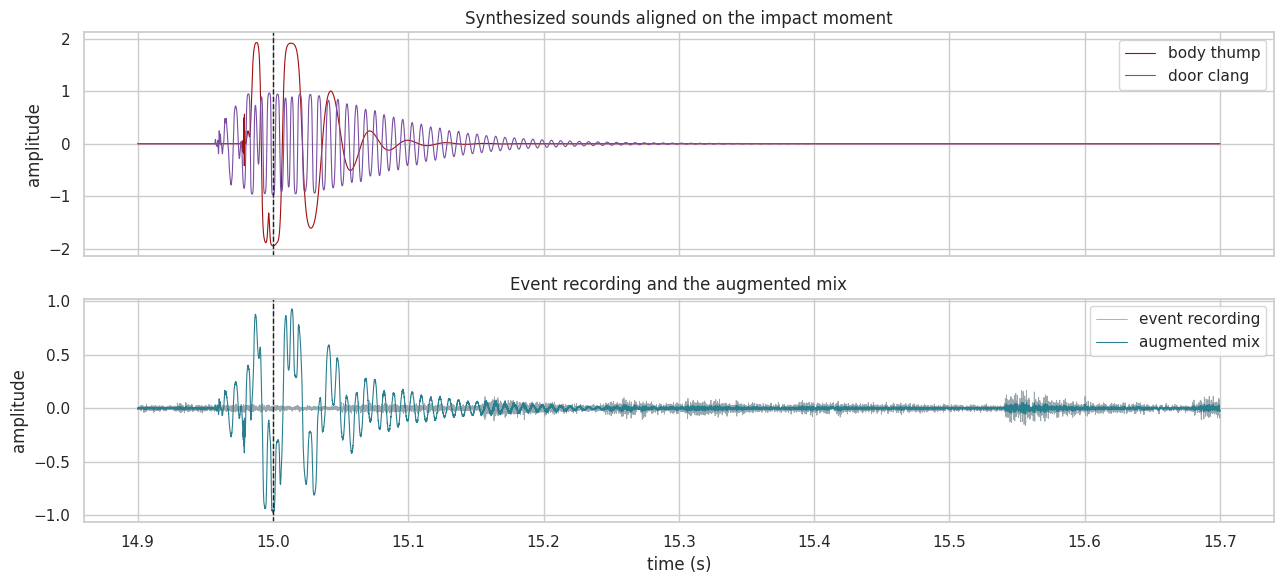

In [6]:
result = mix_event(CFG)
console.print(
    f"peak aligned to sample [white]{result.peak_index:,}[/white] "
    f"([white]{result.peak_index / CFG.sample_rate:.3f} s[/white]); "
    f"clip-limiting gain [white]{result.clip_scale:.3f}[/white]"
)

# zoom on the impact region
lo = max(0, result.peak_index - int(0.10 * CFG.sample_rate))
hi = min(len(result.mixed), result.peak_index + int(0.70 * CFG.sample_rate))
t_zoom = np.arange(lo, hi) / CFG.sample_rate

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax = axes[0]
ax.plot(t_zoom, result.thump_track[lo:hi], color="#a01010", lw=0.8, label="body thump")
ax.plot(t_zoom, result.clang_track[lo:hi], color="#7a4fa3", lw=0.8, label="door clang")
ax.axvline(CFG.peak_time, color="#202020", lw=1.0, ls="--")
ax.set_ylabel("amplitude")
ax.set_title("Synthesized sounds aligned on the impact moment")
ax.legend()
ax = axes[1]
ax.plot(t_zoom, result.event[lo:hi], color="#9aa7ad", lw=0.6, label="event recording")
ax.plot(t_zoom, result.mixed[lo:hi], color="#2a7f8f", lw=0.8, label="augmented mix")
ax.axvline(CFG.peak_time, color="#202020", lw=1.0, ls="--")
ax.set_xlabel("time (s)")
ax.set_ylabel("amplitude")
ax.set_title("Event recording and the augmented mix")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05-augmented-mix.png", dpi=140, bbox_inches="tight")
plt.show()

## Export

The augmented signal is encoded back to an AAC `.m4a` file in the reports figures folder.

In [7]:
out_path = encode_m4a(result.mixed, CFG.output_path, CFG.sample_rate,
                      CFG.output_bitrate)
size_kb = out_path.stat().st_size / 1024
console.print(f"augmented recording written to [cyan]{CFG.output_path}[/cyan] "
              f"([white]{size_kb:.0f} KB[/white], "
              f"{len(result.mixed) / CFG.sample_rate:.1f} s)")

augmented recording written to reports/figures/augmented_event_recording.m4a (421 KB, 26.0 s)

## Summary

- The event-audio augmentation lives in `henryk_simulations.corridor.audiomix` - a library module under the corridor submodule. This notebook is a thin client over its staged functions.
- The body thump (notebook 03) and the door clang (notebook 04) are mixed into the real event recording with their peaks aligned to a configurable moment - `peak_time`, here the 15th second.
- The event recording and the two synthesized sounds are summed and peak-limited; the augmented signal is encoded to `reports/figures/augmented_event_recording.m4a`.
- m4a decode and encode use the ffmpeg binary bundled with `imageio-ffmpeg`, so no system ffmpeg is needed.